# Data-Driven Analysis of Tourism Demand and Spending Patterns in Saudi Arabia

1. Setup and Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

2. Data Loading

In [2]:
dom_province = pd.read_csv('/content/Number of domestic tourists and spending CSV.csv')
dom_purpose  = pd.read_csv('/content/Number of domestic tourists by main purpose CSV 1.csv')
inb_purpose  = pd.read_csv('/content/Number of inbound tourists by main purpose csv.csv')
inb_province = pd.read_csv('/content/Number of inbound tourists spend destination CSV.csv')

print(f'  Domestic by Province : {dom_province.shape[0]} rows, {dom_province.shape[1]} columns')
print(f'  Domestic by Purpose  : {dom_purpose.shape[0]} rows, {dom_purpose.shape[1]} columns')
print(f'  Inbound  by Purpose  : {inb_purpose.shape[0]} rows, {inb_purpose.shape[1]} columns')
print(f'  Inbound  by Province : {inb_province.shape[0]} rows, {inb_province.shape[1]} columns')

  Domestic by Province : 143 rows, 6 columns
  Domestic by Purpose  : 55 rows, 6 columns
  Inbound  by Purpose  : 55 rows, 6 columns
  Inbound  by Province : 141 rows, 6 columns


In [3]:
# preview each dataset
print('--- Domestic by Province ---')
display(dom_province.head(3))
print('\n')

print('--- Domestic by Purpose ---')
display(dom_purpose.head(3))
print('\n')

print('--- Inbound by Purpose ---')
display(inb_purpose.head(3))
print('\n')

print('--- Inbound by Province ---')
display(inb_province.head(3))

--- Domestic by Province ---


,TOURIST TYPE EN,TRIP TYPE,YEAR,DESTINATION PROVINCE NAME EN,Total VISITORS Number,SPENDS by SR
0,DOMESTIC,Overnight,2015,Albaha,"1,041,399","1,119,776,018.55"
1,DOMESTIC,Overnight,2015,Alqassim,"946,993","832,038,134.23"
2,DOMESTIC,Overnight,2015,Aseer,"5,091,717","6,482,489,011.94"




--- Domestic by Purpose ---


,TOURIST TYPE EN,TRIP TYPE,YEAR,VISIT PURPOSE GROUPED EN,VISITORS,SPENDS
0,DOMESTIC,Overnight,2015,Business,"1,859,752","3,247,666,761.42"
1,DOMESTIC,Overnight,2015,Leisure,"19,181,792","21,183,455,240.20"
2,DOMESTIC,Overnight,2015,Other,"2,335,328","4,059,351,265.38"




--- Inbound by Purpose ---


,TOURIST TYPE EN,TRIP TYPE,YEAR,VISIT PURPOSE GROUPED EN,VISITORS,SPENDS
0,INBOUND,Overnight,2015,Business,"1,880,575","10,090,826,436.41"
1,INBOUND,Overnight,2015,Leisure,"1,560,665","4,954,068,163.96"
2,INBOUND,Overnight,2015,Other,"2,392,366","9,067,180,026.90"




--- Inbound by Province ---


,TOURIST TYPE EN,TRIP TYPE,YEAR,DESTINATION PROVINCE NAME EN,VISITORS,SPENDS
0,INBOUND,Overnight,2015,Albaha,"6,092","42,822,952.65"
1,INBOUND,Overnight,2015,Alqassim,"41,902","143,586,806.97"
2,INBOUND,Overnight,2015,Aseer,"59,257","503,026,385.00"


Data Summary

In [4]:
dom_province.info()
print('\n')

dom_purpose.info()
print('\n')

inb_purpose.info()
print('\n')

inb_province.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   TOURIST TYPE EN               143 non-null    object
 1   TRIP TYPE                     143 non-null    object
 2   YEAR                          143 non-null    object
 3   DESTINATION PROVINCE NAME EN  143 non-null    object
 4   Total VISITORS Number         143 non-null    object
 5   SPENDS by SR                  143 non-null    object
dtypes: object(6)
memory usage: 6.8+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   TOURIST TYPE EN           55 non-null     object
 1   TRIP TYPE                 55 non-null     object
 2   YEAR                      55 non-null     object
 3   VISIT PURPOSE

Statistical Description

In [5]:
print('--- Domestic Province ---')
display(dom_province.describe())

print('--- Domestic Purpose ---')
display(dom_purpose.describe())

print('--- Inbound Purpose ---')
display(inb_purpose.describe())

print('--- Inbound Province ---')
display(inb_province.describe())

--- Domestic Province ---


,TOURIST TYPE EN,TRIP TYPE,YEAR,DESTINATION PROVINCE NAME EN,Total VISITORS Number,SPENDS by SR
count,143,143,143,143,143,143
unique,1,1,11,13,143,143
top,DOMESTIC,Overnight,2015,Albaha,"1,041,399","1,119,776,018.55"
freq,143,143,13,11,1,1


--- Domestic Purpose ---


,TOURIST TYPE EN,TRIP TYPE,YEAR,VISIT PURPOSE GROUPED EN,VISITORS,SPENDS
count,55,55,55,55,55,55
unique,1,1,11,5,55,55
top,DOMESTIC,Overnight,2015,Business,"1,859,752","3,247,666,761.42"
freq,55,55,5,11,1,1


--- Inbound Purpose ---


,TOURIST TYPE EN,TRIP TYPE,YEAR,VISIT PURPOSE GROUPED EN,VISITORS,SPENDS
count,55,55,55,55,55,55
unique,1,1,11,5,55,55
top,INBOUND,Overnight,2015,Business,"1,880,575","10,090,826,436.41"
freq,55,55,5,11,1,1


--- Inbound Province ---


,TOURIST TYPE EN,TRIP TYPE,YEAR,DESTINATION PROVINCE NAME EN,VISITORS,SPENDS
count,141,141,141,141,141,141
unique,1,1,11,13,141,141
top,INBOUND,Overnight,2015,Alqassim,"6,092","42,822,952.65"
freq,141,141,13,11,1,1


4. Cleaning function

In [6]:
def clean_dataset(df, visitor_col, spend_col):
    df = df.copy()
    # Remove commas and convert to numbers
    df[visitor_col] = df[visitor_col].astype(str).str.replace(',', '').astype(float)
    df[spend_col] = df[spend_col].astype(str).str.replace(',', '').astype(float)

    # Rename columns for consistency across all files
    df = df.rename(columns={visitor_col: 'VISITORS', spend_col: 'SPENDS'})

    # Convert Year to numeric (encoding 2025 H1 as 2025.5)
    df['YEAR_NUM'] = df['YEAR'].astype(str).apply(lambda x: 2025.5 if 'H1' in x else float(x))

    # Drop "Trip Type" as it's redundant (all are 'Overnight')
    if 'TRIP TYPE' in df.columns:
        df = df.drop(columns=['TRIP TYPE'])
    return df

# Apply the cleaning
dom_province = clean_dataset(dom_province, 'Total VISITORS Number', 'SPENDS by SR')
inb_province = clean_dataset(inb_province, 'VISITORS', 'SPENDS')
dom_purpose  = clean_dataset(dom_purpose, 'VISITORS', 'SPENDS')
inb_purpose  = clean_dataset(inb_purpose, 'VISITORS', 'SPENDS')

# Print cleaning results
for name, df in [('Domestic Province', dom_province), ('Inbound Province', inb_province),
                 ('Domestic Purpose',  dom_purpose),  ('Inbound Purpose',  inb_purpose)]:
    print(f'--- {name} ---')
    print(f'  Shape       : {df.shape[0]} rows x {df.shape[1]} columns')
    print(f'  Columns     : {list(df.columns)}')
    print(f'  Year range  : {int(df["YEAR_NUM"].min())} — 2025 H1')
    print()

--- Domestic Province ---
  Shape       : 143 rows x 6 columns
  Columns     : ['TOURIST TYPE EN', 'YEAR', 'DESTINATION PROVINCE NAME EN', 'VISITORS', 'SPENDS', 'YEAR_NUM']
  Year range  : 2015 — 2025 H1

--- Inbound Province ---
  Shape       : 141 rows x 6 columns
  Columns     : ['TOURIST TYPE EN', 'YEAR', 'DESTINATION PROVINCE NAME EN', 'VISITORS', 'SPENDS', 'YEAR_NUM']
  Year range  : 2015 — 2025 H1

--- Domestic Purpose ---
  Shape       : 55 rows x 6 columns
  Columns     : ['TOURIST TYPE EN', 'YEAR', 'VISIT PURPOSE GROUPED EN', 'VISITORS', 'SPENDS', 'YEAR_NUM']
  Year range  : 2015 — 2025 H1

--- Inbound Purpose ---
  Shape       : 55 rows x 6 columns
  Columns     : ['TOURIST TYPE EN', 'YEAR', 'VISIT PURPOSE GROUPED EN', 'VISITORS', 'SPENDS', 'YEAR_NUM']
  Year range  : 2015 — 2025 H1



4. Missing Values

---



In [7]:
# Check for missing values across all 4 datasets
datasets = {
    'Domestic (Province)': dom_province,
    'Inbound (Province)':  inb_province,
    'Domestic (Purpose)':  dom_purpose,
    'Inbound (Purpose)':   inb_purpose
}

for name, df in datasets.items():
    print(f"--- {name} ---")
    print(f"Missing Values: {df.isnull().sum().sum()}")
    print("-" * 30)

--- Domestic (Province) ---
Missing Values: 0
------------------------------
--- Inbound (Province) ---
Missing Values: 0
------------------------------
--- Domestic (Purpose) ---
Missing Values: 0
------------------------------
--- Inbound (Purpose) ---
Missing Values: 0
------------------------------


6. Outlier Identification

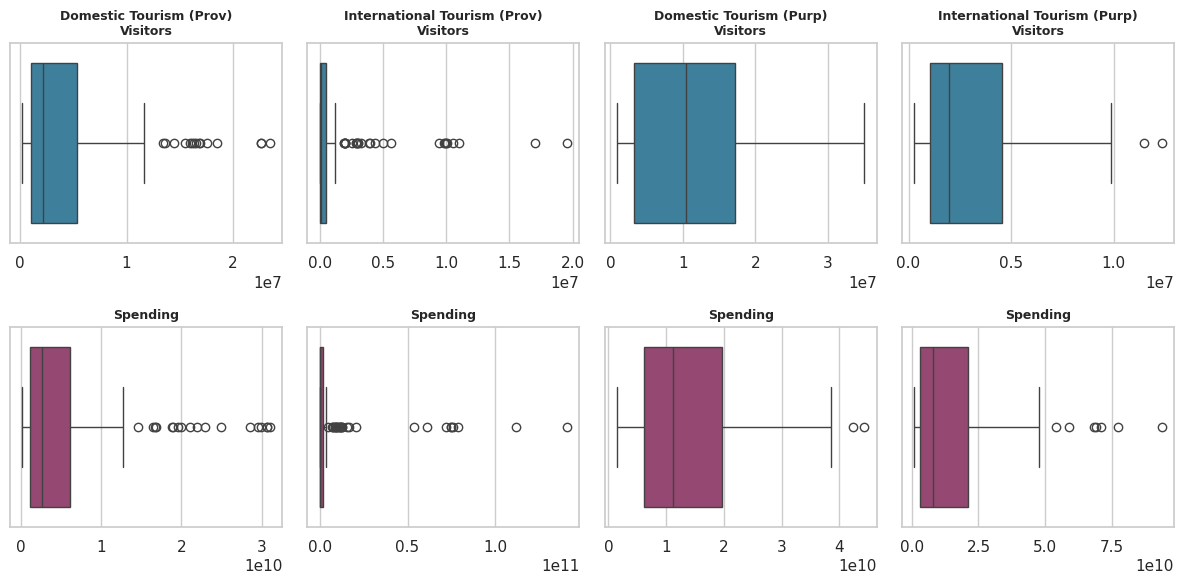

In [8]:
# 1. Define the datasets with consistent terminology
outlier_datasets = {
    'Domestic Tourism (Prov)': dom_province,
    'International Tourism (Prov)': inb_province,
    'Domestic Tourism (Purp)': dom_purpose,
    'International Tourism (Purp)': inb_purpose
}

# 2. Create a compact 2x4 grid (Row 1: Visitors, Row 2: Spends)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, (name, df) in enumerate(outlier_datasets.items()):
    # Row 0: Visitors
    sns.boxplot(data=df, x='VISITORS', ax=axes[0, i], color='#2E86AB')
    axes[0, i].set_title(f'{name}\nVisitors', fontsize=9, fontweight='bold')
    axes[0, i].set_xlabel('')
    # Row 1: Spending
    sns.boxplot(data=df, x='SPENDS', ax=axes[1, i], color='#A23B72')
    axes[1, i].set_title(f'Spending', fontsize=9, fontweight='bold')
    axes[1, i].set_xlabel('')

# 3. Apply 95th Percentile Capping to all 4 datasets
for name, df in outlier_datasets.items():
    v_limit = df['VISITORS'].quantile(0.95)
    df['VISITORS_CAPPED'] = df['VISITORS'].clip(upper=v_limit)

    s_limit = df['SPENDS'].quantile(0.95)
    df['SPENDS_CAPPED'] = df['SPENDS'].clip(upper=s_limit)

plt.tight_layout()
plt.show()

5. Feature Engineering (Add New Feature: Spend per Tourist)

In [9]:
for df in [dom_province, inb_province, dom_purpose, inb_purpose]:
    df['SPEND_PER_TOURIST'] = df['SPENDS'] / df['VISITORS']

print('Sample values from Domestic Purpose:')
display(dom_purpose[['YEAR', 'VISIT PURPOSE GROUPED EN', 'VISITORS', 'SPENDS', 'SPEND_PER_TOURIST']].head(5))

Sample values from Domestic Purpose:


,YEAR,VISIT PURPOSE GROUPED EN,VISITORS,SPENDS,SPEND_PER_TOURIST
0,2015,Business,1859752.0,3.247667e+09,1746.290237
1,2015,Leisure,19181792.0,2.118346e+10,1104.352254
2,2015,Other,2335328.0,4.059351e+09,1738.236027
3,2015,Religious,11972476.0,1.015693e+10,848.356278
4,2015,VFR,11101085.0,9.771687e+09,880.246154


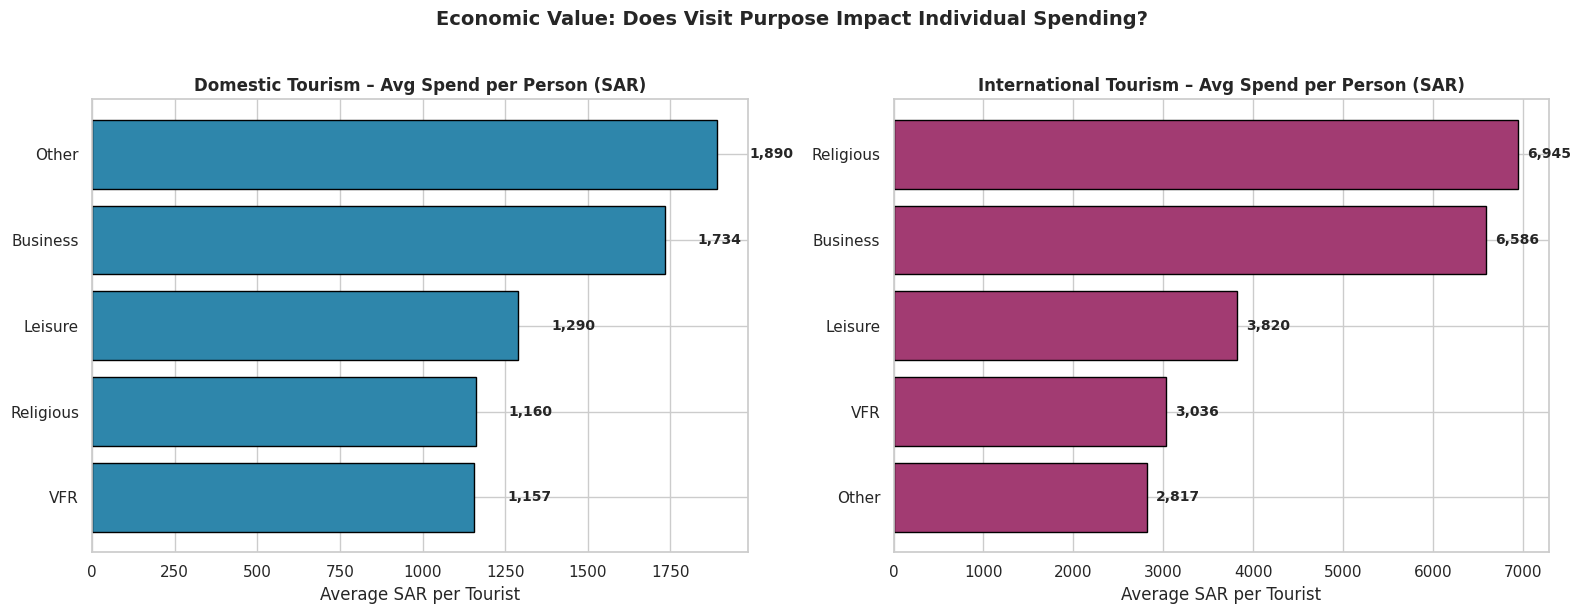

Observation: This comparison reveals that while certain purposes attract high volume,
others generate significantly higher economic value per individual tourist.


In [10]:
# --- EDA: Average Spend per Tourist by Purpose Comparison ---

# 1. Define related labels and specific project colors
# Inbound is renamed to International Tourism to share the 'Tourism' lemma
labels = {'Domestic': 'Domestic Tourism', 'Inbound': 'International Tourism'}
colors = {'Domestic': '#2E86AB', 'Inbound': '#A23B72'}

# 2. Create side-by-side horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (key, df) in enumerate([('Domestic', dom_purpose), ('Inbound', inb_purpose)]):
    # Calculate mean spend per tourist by purpose and sort for readability
    avg_spt = df.groupby('VISIT PURPOSE GROUPED EN')['SPEND_PER_TOURIST'].mean().sort_values(ascending=True)

    # Plotting horizontal bars with specific project colors
    axes[i].barh(avg_spt.index, avg_spt.values, color=colors[key], edgecolor='black')

    # Titles and Labels
    axes[i].set_title(f'{labels[key]} – Avg Spend per Person (SAR)', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Average SAR per Tourist')

    # Add data labels directly to the bars for clarity
    for j, val in enumerate(avg_spt.values):
        axes[i].text(val + 100, j, f'{val:,.0f}', va='center', fontweight='bold', fontsize=10)

# 3. Final visual
plt.suptitle('Economic Value: Does Visit Purpose Impact Individual Spending?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Save for your final report
plt.savefig('eda_spend_per_purpose.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation: This comparison reveals that while certain purposes attract high volume,')
print('others generate significantly higher economic value per individual tourist.')

7. Log Transformation (Normalization)

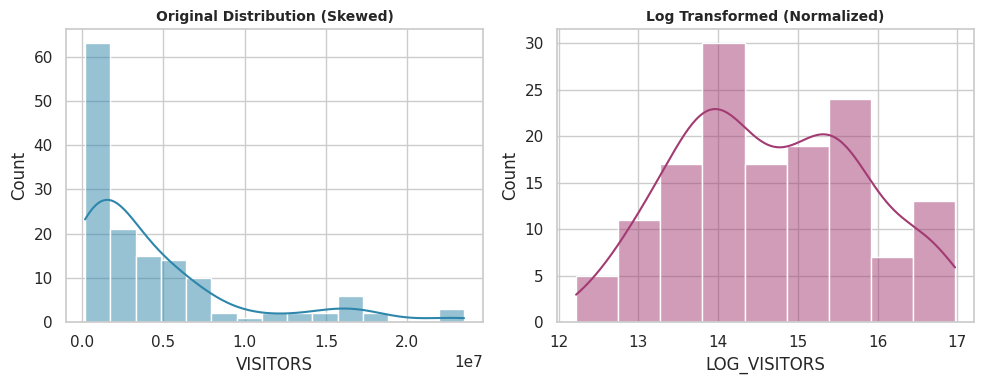

In [11]:
# 1. Define the datasets to transform
datasets_to_transform = {
    'Domestic (Province)': dom_province,
    'International (Province)': inb_province,
    'Domestic (Purpose)': dom_purpose,
    'International (Purpose)': inb_purpose
}

# 2. Apply np.log1p (Log + 1) to handle zeros and normalize data
for name, df in datasets_to_transform.items():
    df['LOG_VISITORS'] = np.log1p(df['VISITORS'])
    df['LOG_SPENDS'] = np.log1p(df['SPENDS'])

# 3. Visualize the effect (Example: Domestic Province)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Original Distribution (Skewed)
sns.histplot(dom_province['VISITORS'], kde=True, ax=ax1, color='#2E86AB')
ax1.set_title('Original Distribution (Skewed)', fontsize=10, fontweight='bold')

# Log Transformed (Normalized)
sns.histplot(dom_province['LOG_VISITORS'], kde=True, ax=ax2, color='#A23B72')
ax2.set_title('Log Transformed (Normalized)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

##EDA

8. 1 Growth Trends

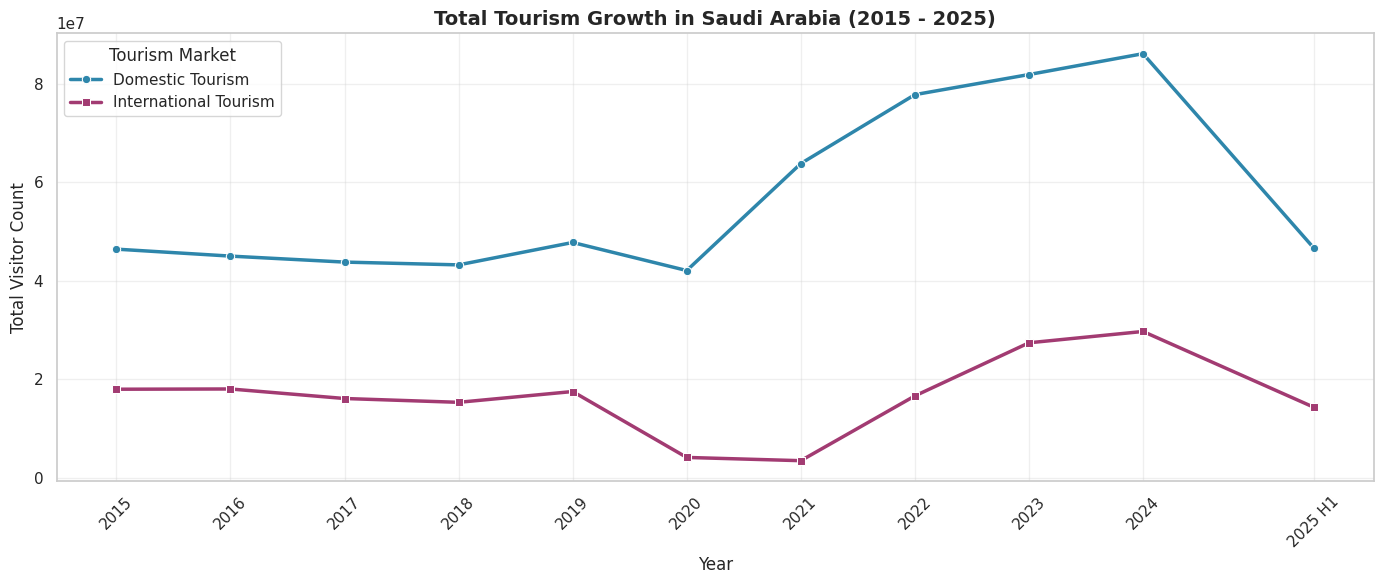

In [ ]:
# 1. Prepare unique years for the X-axis
all_years = sorted(dom_province['YEAR_NUM'].unique())

def year_label(y):
    # This ensures 2025.5 displays as '2025 H1' and others as full years
    return '2025 H1' if y == 2025.5 else str(int(y))

# 2. Aggregate visitor counts for each year
dom_trend = dom_province.groupby('YEAR_NUM')['VISITORS'].sum().reset_index()
inb_trend = inb_province.groupby('YEAR_NUM')['VISITORS'].sum().reset_index()

# 3. Create the Visualization
plt.figure(figsize=(14, 6))

# Plot Domestic Tourism Line
sns.lineplot(data=dom_trend, x='YEAR_NUM', y='VISITORS',
             label='Domestic Tourism', marker='o', linewidth=2.5, color='#2E86AB')

# Plot International Tourism Line (using standard project color, no red)
sns.lineplot(data=inb_trend, x='YEAR_NUM', y='VISITORS',
             label='International Tourism', marker='s', linewidth=2.5, color='#A23B72')

# 4. Formatting the X-Axis
plt.xticks(all_years, [year_label(y) for y in all_years], rotation=45)

# 5. Final Chart Labels
plt.title('Total Tourism Growth in Saudi Arabia (2015 - 2025)', fontsize=14, fontweight='bold')
plt.ylabel('Total Visitor Count')
plt.xlabel('Year')
plt.legend(title='Tourism Market')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

8. 2. Regional Visitor Trends Over Time

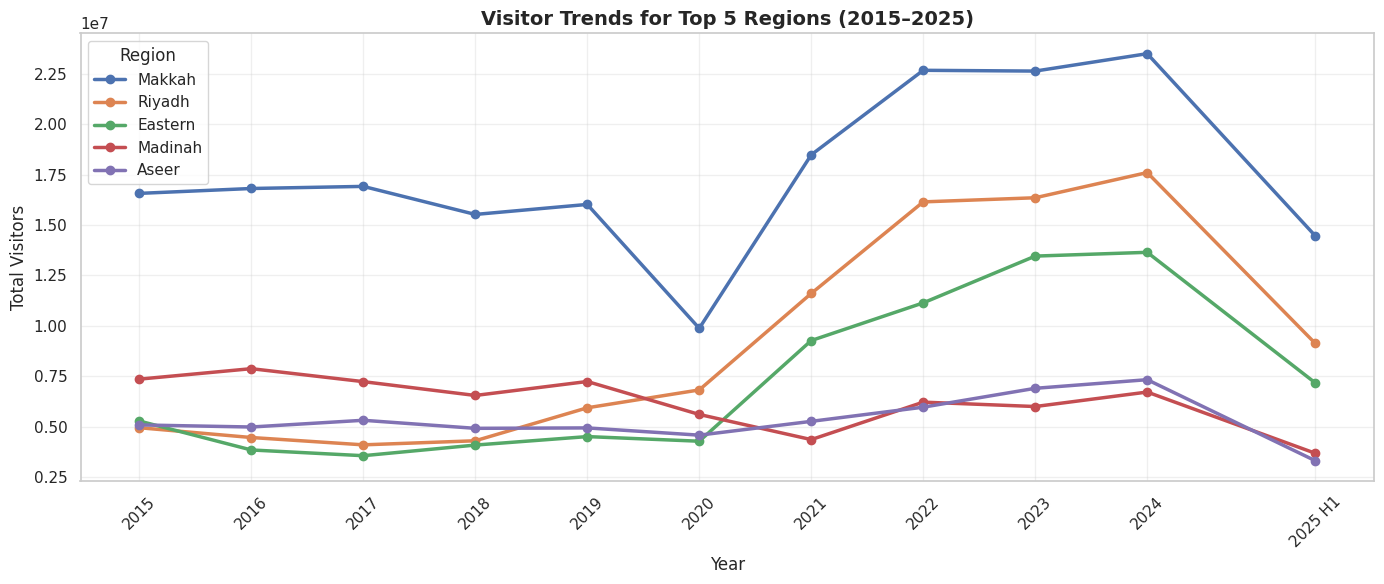

In [ ]:
top5_regions = (dom_province.groupby('DESTINATION PROVINCE NAME EN')['VISITORS']
                .mean()
                .sort_values(ascending=False)
                .head(5)
                .index.tolist())

top5_data = dom_province[dom_province['DESTINATION PROVINCE NAME EN'].isin(top5_regions)]

all_years = sorted(top5_data['YEAR_NUM'].unique())

plt.figure(figsize=(14, 6))

for region in top5_regions:
    region_data = top5_data[top5_data['DESTINATION PROVINCE NAME EN'] == region]
    region_trend = region_data.groupby('YEAR_NUM')['VISITORS'].sum().reset_index()
    plt.plot(region_trend['YEAR_NUM'], region_trend['VISITORS'],
             marker='o', linewidth=2.5, label=region)

plt.xticks(all_years, ['2025 H1' if y == 2025.5 else str(int(y)) for y in all_years], rotation=45)
plt.title('Visitor Trends for Top 5 Regions (2015–2025)', fontsize=14, fontweight='bold')
plt.ylabel('Total Visitors')
plt.xlabel('Year')
plt.legend(title='Region')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

8. 3  Comparing Visitor Volume and Spending Shares

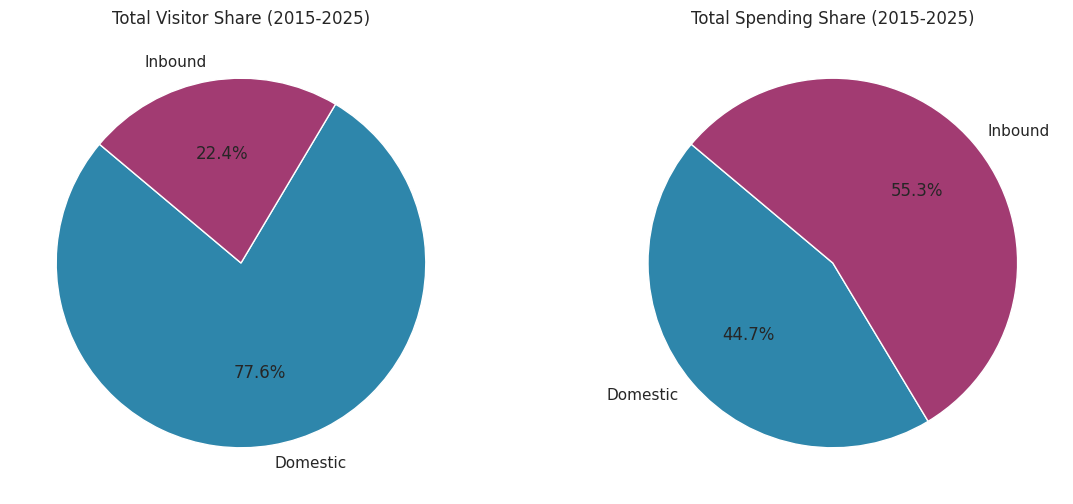

In [ ]:
# Aggregate totals
visitor_totals = df_compare.groupby('TOURIST_TYPE')['VISITORS'].sum()
spend_totals = df_compare.groupby('TOURIST_TYPE')['SPENDS'].sum()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot Visitor Share
ax[0].pie(visitor_totals, labels=visitor_totals.index, autopct='%1.1f%%',
          colors=[COLORS['Domestic'], COLORS['Inbound']], startangle=140)
ax[0].set_title('Total Visitor Share (2015-2025)')

# Plot Spending Share
ax[1].pie(spend_totals, labels=spend_totals.index, autopct='%1.1f%%',
          colors=[COLORS['Domestic'], COLORS['Inbound']], startangle=140)
ax[1].set_title('Total Spending Share (2015-2025)')

plt.show()

8. 4. Comparing Average Spending per Tourist



/tmp/ipykernel_235/2992240595.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  yearly_avg_spend = df_compare.groupby(['YEAR_NUM', 'TOURIST_TYPE']).apply(


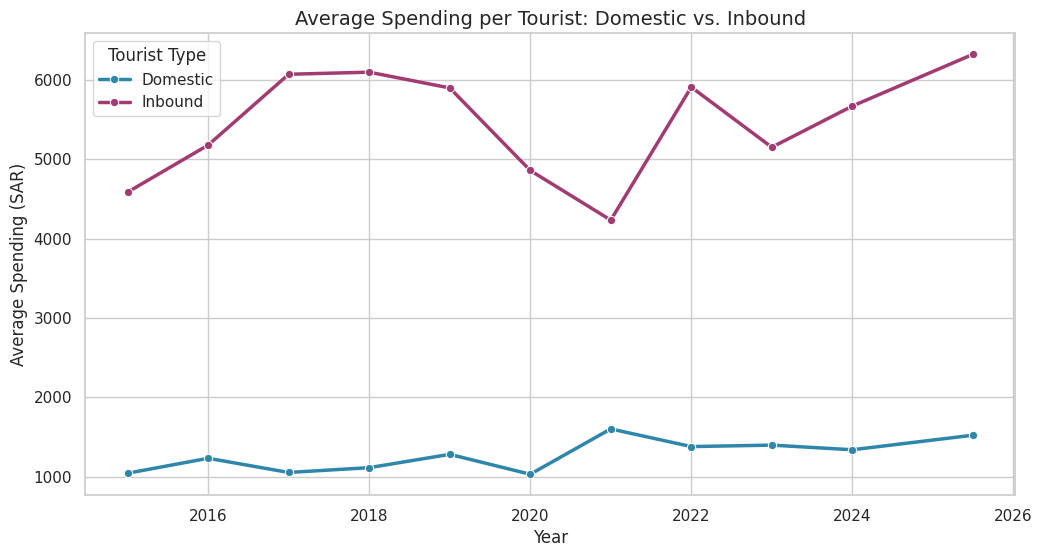

In [ ]:
# Calculate annual average spend per person for both types
yearly_avg_spend = df_compare.groupby(['YEAR_NUM', 'TOURIST_TYPE']).apply(
    lambda x: x['SPENDS'].sum() / x['VISITORS'].sum()
).reset_index(name='AVG_SPEND')

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_avg_spend, x='YEAR_NUM', y='AVG_SPEND', hue='TOURIST_TYPE',
             palette=COLORS, marker='o', linewidth=2.5)

plt.title('Average Spending per Tourist: Domestic vs. Inbound', fontsize=14)
plt.ylabel('Average Spending (SAR)')
plt.xlabel('Year')
plt.legend(title='Tourist Type')
plt.show()

8. 5 Comparing Travel Purposes

In [ ]:
# Combine domestic and inbound purpose datasets for comparison
dom_purpose['TOURIST_TYPE'] = 'Domestic'
inb_purpose['TOURIST_TYPE'] = 'Inbound'

# Concatenate them into one dataframe
df_compare = pd.concat([dom_purpose, inb_purpose], ignore_index=True)

# Define standard colors for visual consistency
COLORS = {'Domestic': '#2E86AB', 'Inbound': '#A23B72'}

print("Comparison dataset created with columns:", df_compare.columns.tolist())

Comparison dataset created with columns: ['TOURIST TYPE EN', 'YEAR', 'VISIT PURPOSE GROUPED EN', 'VISITORS', 'SPENDS', 'YEAR_NUM', 'VISITORS_CAPPED', 'SPENDS_CAPPED', 'SPEND_PER_TOURIST', 'LOG_VISITORS', 'LOG_SPENDS', 'TOURIST_TYPE']


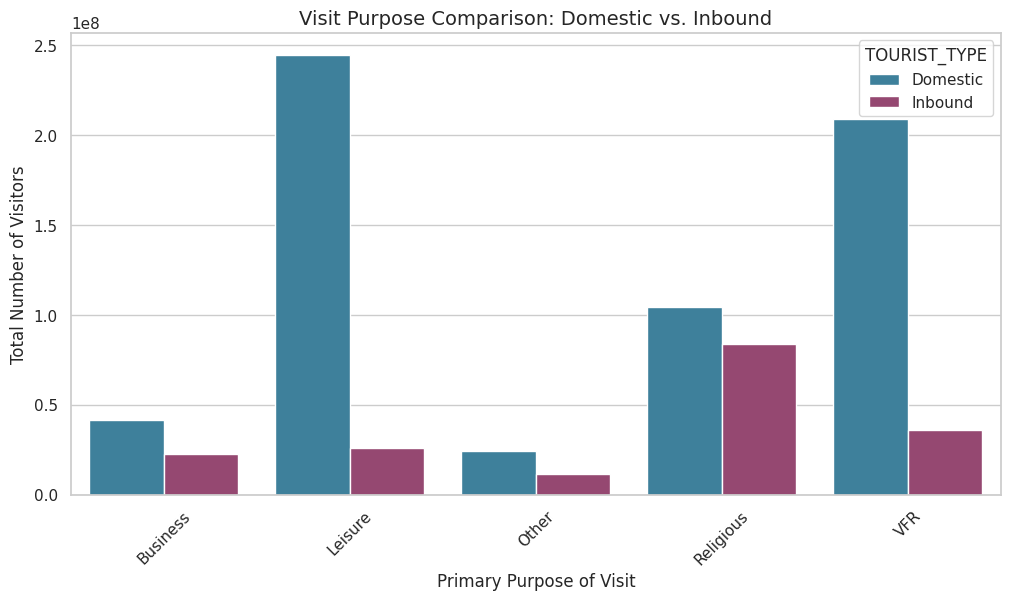

In [ ]:
# Aggregate visitors by purpose and type
purpose_compare = df_compare.groupby(['VISIT PURPOSE GROUPED EN', 'TOURIST_TYPE'])['VISITORS'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=purpose_compare, x='VISIT PURPOSE GROUPED EN', y='VISITORS', hue='TOURIST_TYPE', palette=COLORS)

plt.title('Visit Purpose Comparison: Domestic vs. Inbound', fontsize=14)
plt.ylabel('Total Number of Visitors')
plt.xlabel('Primary Purpose of Visit')
plt.xticks(rotation=45)
plt.show()

8. 6. Tourism by Destination Comparison

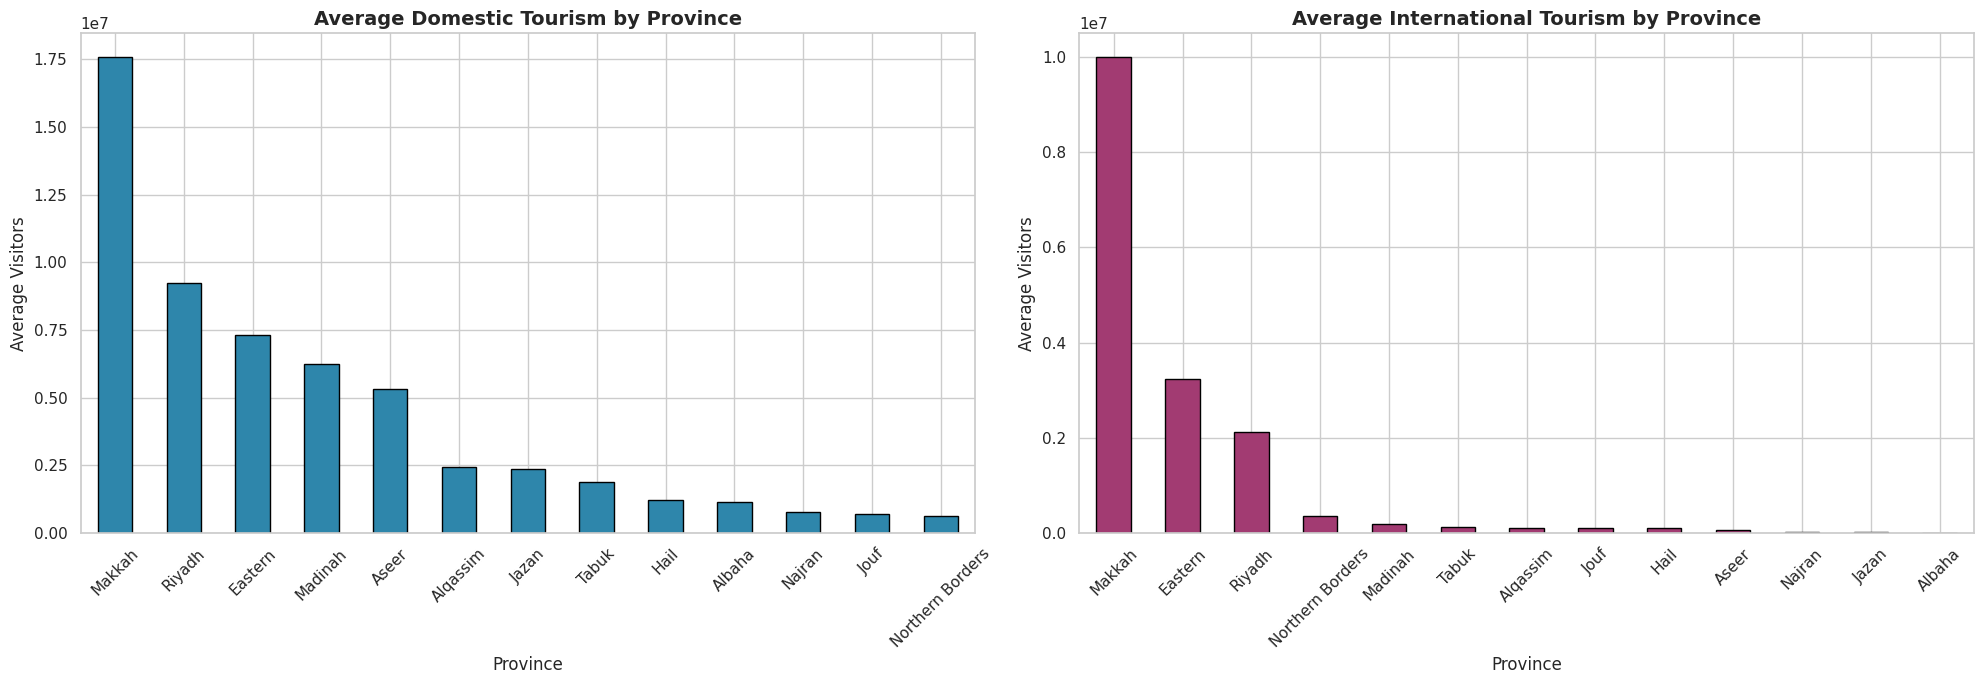

In [ ]:
# 1. Prepare Average Data for both types
top_dest_dom = dom_province.groupby('DESTINATION PROVINCE NAME EN')['VISITORS'].mean().sort_values(ascending=False)
top_dest_inb = inb_province.groupby('DESTINATION PROVINCE NAME EN')['VISITORS'].mean().sort_values(ascending=False)

# 2. Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=False)

# Chart A: Domestic Tourism
top_dest_dom.plot(kind='bar', ax=axes[0], color='#2E86AB', edgecolor='black')
axes[0].set_title('Average Domestic Tourism by Province', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Visitors')
axes[0].set_xlabel('Province')
axes[0].tick_params(axis='x', rotation=45)

# Chart B: International Tourism (Renamed from Inbound)
top_dest_inb.plot(kind='bar', ax=axes[1], color='#A23B72', edgecolor='black')
axes[1].set_title('Average International Tourism by Province', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Visitors')
axes[1].set_xlabel('Province')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

9. Correlation Analysis

9. 1. Relationship Between Visitor Volume and Total Spending

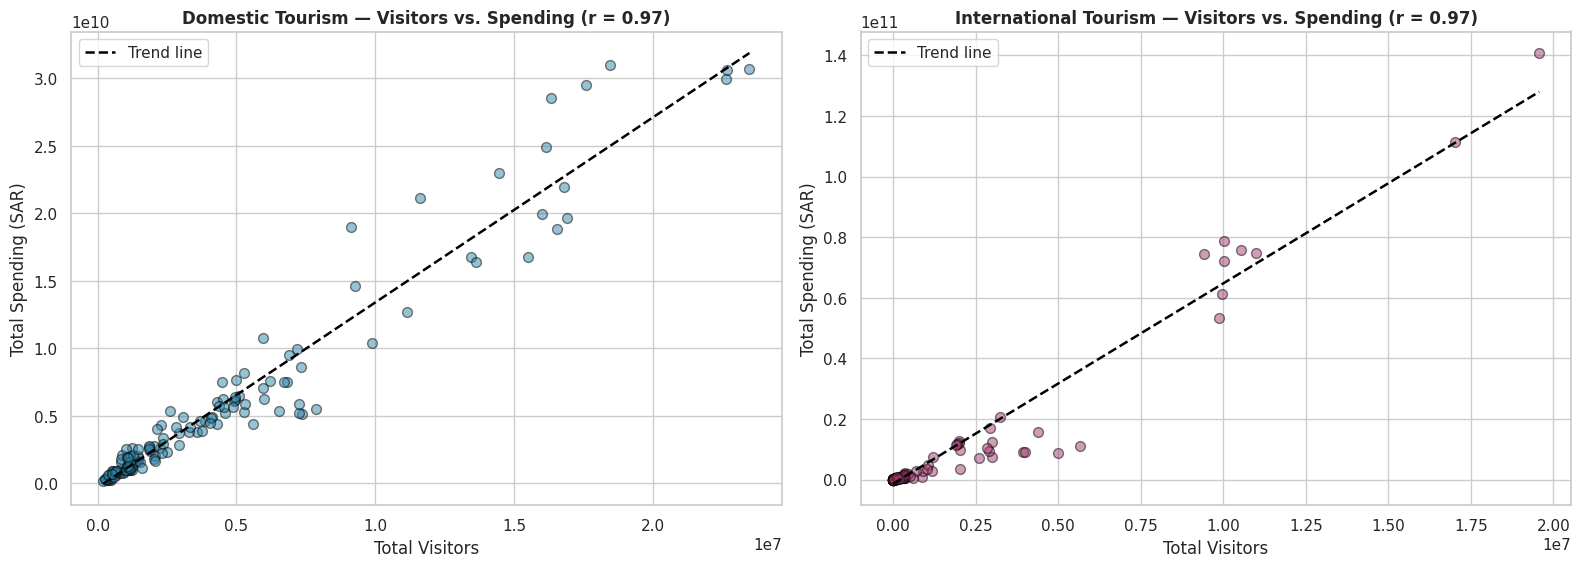

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label, df) in enumerate([('Domestic Tourism', dom_province), ('International Tourism', inb_province)]):
    color = '#2E86AB' if i == 0 else '#A23B72'
    axes[i].scatter(df['VISITORS'], df['SPENDS'], color=color, alpha=0.5, edgecolors='black', s=50)

    m, b = np.polyfit(df['VISITORS'], df['SPENDS'], 1)
    x_line = np.linspace(df['VISITORS'].min(), df['VISITORS'].max(), 200)
    axes[i].plot(x_line, m * x_line + b, color='black', linewidth=1.8, linestyle='--', label='Trend line')

    r = df['VISITORS'].corr(df['SPENDS'])
    axes[i].set_title(f'{label} — Visitors vs. Spending (r = {r:.2f})', fontweight='bold')
    axes[i].set_xlabel('Total Visitors')
    axes[i].set_ylabel('Total Spending (SAR)')
    axes[i].legend()

plt.tight_layout()
plt.show()

9. 2. Feature Correlation Heatmaps Across All Datasets

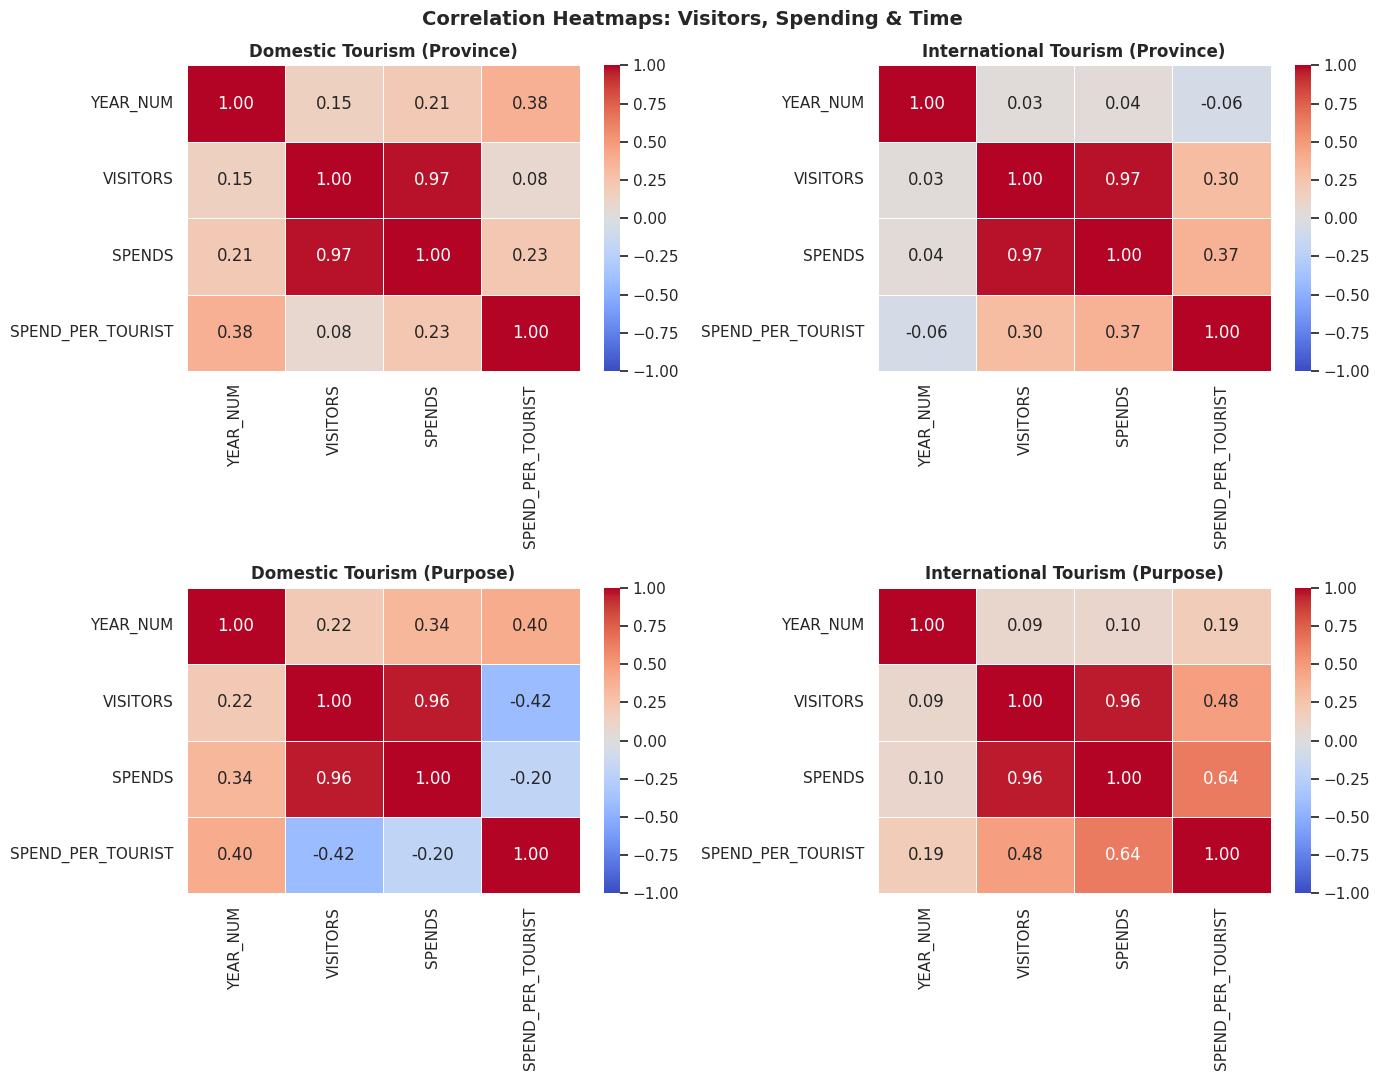

In [ ]:
numeric_cols = ['YEAR_NUM', 'VISITORS', 'SPENDS', 'SPEND_PER_TOURIST']

heatmap_datasets = {
    'Domestic Tourism (Province)':      dom_province,
    'International Tourism (Province)': inb_province,
    'Domestic Tourism (Purpose)':       dom_purpose,
    'International Tourism (Purpose)':  inb_purpose
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, (name, df) in zip(axes.flatten(), heatmap_datasets.items()):
    sns.heatmap(df[numeric_cols].corr(), ax=ax, annot=True, fmt='.2f',
                cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, linecolor='white')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Correlation Heatmaps: Visitors, Spending & Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

9. 3. Pearson Correlation Summary

In [ ]:
summary_rows = []

for name, df in heatmap_datasets.items():
    summary_rows.append({
        'Dataset':               name,
        'Visitors vs Spending':  round(df['VISITORS'].corr(df['SPENDS']), 2),
        'Visitors vs Year':      round(df['VISITORS'].corr(df['YEAR_NUM']), 2),
        'Spending vs Year':      round(df['SPENDS'].corr(df['YEAR_NUM']), 2),
        'Spend/Tourist vs Year': round(df['SPEND_PER_TOURIST'].corr(df['YEAR_NUM']), 2),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Dataset')

def highlight(val):
    if abs(val) >= 0.7: return 'background-color: #1a6b3c; color: white; font-weight: bold'
    elif abs(val) >= 0.4: return 'background-color: #fff3cd; color: black'
    return 'color: white'

display(summary_df.style.map(highlight))

,Visitors vs Spending,Visitors vs Year,Spending vs Year,Spend/Tourist vs Year
Dataset,,,,
Domestic Tourism (Province),0.970000,0.150000,0.210000,0.380000
International Tourism (Province),0.970000,0.030000,0.040000,-0.060000
Domestic Tourism (Purpose),0.960000,0.220000,0.340000,0.400000
International Tourism (Purpose),0.960000,0.090000,0.100000,0.190000


In [12]:
from google.colab import files

# Define the processed datasets you created
processed_files = {
    'processed_domestic_province.csv': dom_province,
    'processed_inbound_province.csv': inb_province,
    'processed_domestic_purpose.csv': dom_purpose,
    'processed_inbound_purpose.csv': inb_purpose
}

# Export each to CSV
for filename, df in processed_files.items():
    df.to_csv(filename, index=False)
    files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>